# <u>AdaBoosting Regression</u>

### Prerequisites:

* <a href="../7.Descision Trees Regression/Descision Trees Regression.ipynb">Check out the notebookes on Decision Tree Classifier</a>
* <a href="..//8.Random Forest Regression/Random Forest Regression.ipynb">Check out the notebooks on Random Forest Classification</a>

## Topics

* [1. What is Boosting?](#what)
* [2. Boosting vs. Bagging](#vs)
* [3. Adaptive Boosting Regression](#ada)


<a href="../../2.Classification/9.AdaBoost Classifier/Adaboost Classification.ipynb">Check out the notebook on Adaboost Classification for more code</a>



In [ ]:
import numpy as np # for arrays and random numbers
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting
from plotly.subplots import make_subplots # for plotting as a grid

from sklearn.tree import (
    DecisionTreeClassifier, # for Classification Trees
    DecisionTreeRegressor # for Regression Trees
)

from sklearn import tree # to plot Trees

import pandas as pd # dataframes

from sklearn.ensemble import (
    AdaBoostClassifier, # for AdaBoost in Classification
    AdaBoostRegressor, # for Adaboost in Regression
    GradientBoostingClassifier, # Gradient Boosting Classification
    GradientBoostingRegressor, # Gradient Boosting Regression
    HistGradientBoostingClassifier, # Histogram-based Gradient Boosting for Classification
    HistGradientBoostingRegressor, # Histogram-based Gradient Boosting for Regression
    RandomForestClassifier, # for Random Forest Classification
    RandomForestRegressor # for Random Forest Regression
)

# XGBoost
#from xgboost import XGBClassifier, XGBRegressor

# LightGBM
#from lightgbm import LGBMClassifier, LGBMRegressor

# CatBoost
#from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.datasets import make_classification # toy data for classification
from sklearn.datasets import make_regression # toy data for regression

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score

from sklearn.datasets import make_regression # make data for Regression
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error

print("Setup complete")

Setup complete


<a class="anchor" id="what"></a>
# 1. What is Boosting?

- Boosting is an ensemble learning technique that combines many weak learners into a strong predictive model
- **Idea:** <u>Sequentially</u> apply a weak learner to <u>modified versions of the training data</u> with more focus on difficult observations
- Typical weak learners are decision trees and tree stumps (1-level decision trees)
- Boosting can be used fpr Classification, Regression and multiclass porblemns
- Weak learners are a prediction rule with a correct classification rate only slightly better than random guessing (so above 50% accuracy)

<a class="anchor" id="vs"></a>
# 2. Boosting vs. Bagging


<div style="display:flex; gap:20px;">

<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Bagging / Random Forests
- Base learners are decision trees
- Base learners are trained independently
- Equal weighting for base learners
- Goal: Mainly reduces variance
- Usually resistant to overfitting



</div>

<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Boosting
- Base learners are (most commonly) weak decision trees 
- Base learners are trained sequentially
- Following base learners focus on errors of previous base learners
- Different weighting for different base learners
- Goal: Reduces both bias and variance
- More prone to overfitting

</div>
</div>

<p align="center">
<img src="pics/1_.png" width="500"/>
</p>


<a class="anchor" id="ada"></a>
# 3. Adaptive Boosting Regression


**Adaboost Regression algorithm with Regression Trees:**

1. Initialize sample weights $w^{[1](i)}=\frac{1}{n} \hspace{2 mm} \forall i \in \{1,\ldots,n\}$ (so $\sum_{i=1}^n w^{[1](i)}=1$) on original dataset $\mathcal{D}$
2. for $m=1$ to $M$ do
    - Bootstrap sample from original data set $\mathcal{D}$ according to sample weights to get bootstrap sample data $\mathcal{D}_B$
    - Fit regression tree of depth 1 (our weak base learner) $\hat{f}^{[m]}$ to bootstrap sample data $\mathcal{D}_B$
    - Calculate absolute prediction erros on original data set $\mathcal{D}$:
    $$
    e^{(i)} = \left| y^{(i)} - \hat{f}^{[m]}(x^{(i)}) \right|
    $$
    - Normalize errors (divide all errors by maximum error):
    $$
    \tilde{e}^{(i)}=\frac{e^{(i)}}{\max e^{(i)} + \varepsilon} \in [0,1] \text{ (add small positive $\varepsilon$ to avoid zero division)}
    $$
    - Compute weighted error:
    $$
    \text{weighted\_error}^{[m]}=\frac{\sum_{i=1}^nw^{[m](i)}\tilde{e}^{(i)}}{\sum_{i=1}^nw^{[m](i)}} \begin{cases} \text{weighted\_error}^{[m]} < 0.5 \text{ AdaBoost will give $\hat{f}^{[m]}$ high importance}  \\ \text{weighted\_error}^{[m]} \geq 0.5 \text{ AdaBoost will give $\hat{f}^{[m]}$ little importance}   \end{cases}
    $$
    
    - Compute relative accuracy of the base learner $\hat{f}^{[m]}$: 
    $$
    \beta^{[m]} = \frac{\text{weighted\_error}^{[m]}}{1-\text{weighted\_error}^{[m]}} \begin{cases} \beta^{[m]} \text{ is small $\rightarrow$ good base leraner},  &\text{ if weigted\_error is low}  \\  \beta^{[m]} \text{ is large $\rightarrow$ bad base leraner},  &\text{ if weigted\_error is large}  \end{cases}
    $$

    - Compute base learner weight (determines importance of the base learner in final predictions): 
    $$
    \underbrace{\alpha^{[m]}=\eta \cdot \ln(\frac{1}{\beta^{[m]}}) \text{ with $\eta \in [0,1]$ predefined learning rate}}_{\text{Weak learners with smaller errors contribute more to the model}}
    $$ 


    - Set new sample weights: 
    $$
    w^{[m+1](i)}=w^{[m](i)} \cdot \left(\beta^{[m]}\right)^{(1-\tilde{e}^{(i)})\cdot \eta}
    $$
    
    - Normalize $w^{[m+1](i)}$ such that $\sum_{i=1}^n w^{[m+1](i)}=1$ (divide each new weight by the sum of the new weights)
3. end for
4. Output ensemble predictor:
$$
\hat{f}(x)=\mathrm{WeightedMedian}\left(\{(\hat f^{[m]}(x), \alpha^{[m]})\}_{m=1}^M\right)
$$

Classical AdaBoost.R2 often trains directly with weighted samples rather than explicitly bootstrap-resampling them.

Meaning:
- many implementations pass sample_weight directly into the regression tree learner,
- instead of generating $\mathcal{D}_B$


<p align="center">
<img src="pics/2.jpg" width="500"/>
</p>

----

**Make a new collection of samples with duplicate copies of samples with largest sample weights**
- Pick a random number r between 0 and 1 and see where that number falls when treating the sample weights as a distribution
- If r $\in [0,0.2]$ put the sample with the index 1 inside the collection 
- If r $\in [0.2,0.4]$ put the sample with the index 2 inside the collection  
- If r $\in [0.4,0.6]$ put the sample with the index 3 inside the collection 
- If r $\in [0.6,0.8]$ put the sample with the index 4 inside the collection 
- If r $\in [0.8,1]$ put the sample with the index 4 inside the collection 

<p align="center">
<img src="pics/3.jpg" width="500"/>
</p>

Round 1
Weighted Error: 0.2339
Alpha: 0.5933
----------------------------------------
Round 2
Weighted Error: 0.2934
Alpha: 0.4395
----------------------------------------
Round 3
Weighted Error: 0.2929
Alpha: 0.4406
----------------------------------------
Round 4
Weighted Error: 0.2785
Alpha: 0.4760
----------------------------------------
Round 5
Weighted Error: 0.2828
Alpha: 0.4653
----------------------------------------
Round 6
Weighted Error: 0.3317
Alpha: 0.3503
----------------------------------------
Round 7
Weighted Error: 0.3875
Alpha: 0.2288
----------------------------------------
Round 8
Weighted Error: 0.3444
Alpha: 0.3219
----------------------------------------
Round 9
Weighted Error: 0.3799
Alpha: 0.2451
----------------------------------------
Round 10
Weighted Error: 0.3683
Alpha: 0.2698
----------------------------------------
Round 11
Weighted Error: 0.4467
Alpha: 0.1070
----------------------------------------
Round 12
Weighted Error: 0.4097
Alpha: 0.1826
------

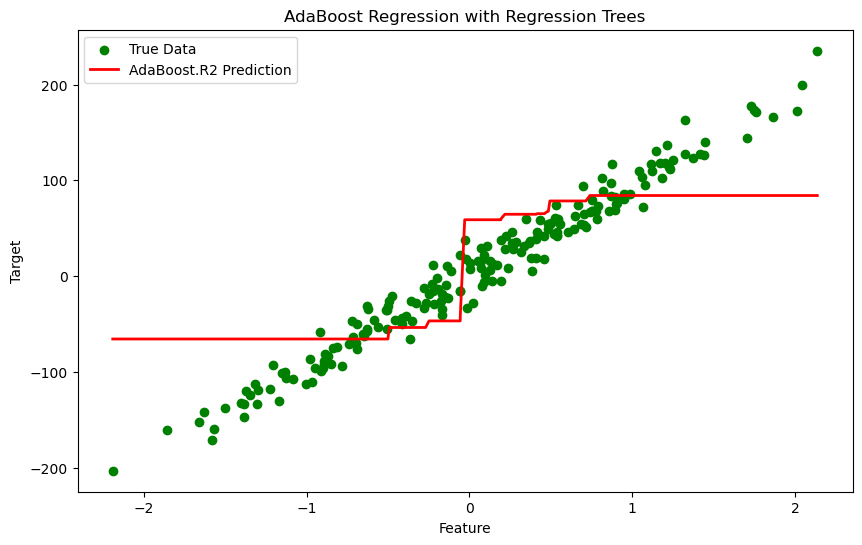

In [6]:
# Generate regression data
X, y = make_regression(n_samples=200,n_features=1,noise=15,random_state=1415)

# Sort data for cleaner plotting
sorted_idx = np.argsort(X[:, 0])

X = X[sorted_idx]
y = y[sorted_idx]


# AdaBoost.R2 parameters
M = 20
learning_rate = 0.5
max_depth = 1
n = len(y)

# Initialize sample weights
weights = np.ones(n) / n
models = []
alphas = []

# Boosting loop
for m in range(M):


    # Bootstrap sampling using sample weights
    bootstrap_indices = np.random.choice(np.arange(n),size=n,replace=True,p=weights)

    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]


    # Train regression stump
    tree = DecisionTreeRegressor(max_depth=max_depth,random_state=1415)
    tree.fit(X_boot, y_boot)

    # Predict on ORIGINAL dataset
    y_pred = tree.predict(X)

    # Absolute errors
    errors = np.abs(y - y_pred)


    # Normalize errors
    eps = 1e-10
    normalized_errors = errors / (np.max(errors) + eps)


    # Weighted error
    weighted_error = np.sum(weights * normalized_errors) # no denominator neede since weights add up to 1

    weighted_error = np.clip(weighted_error,1e-10,1 - 1e-10) # make sure weighted error is nver 0 or 1
    # 1e-10 is 10^(-10) and 1-1e-10 is 1-10^(-10)
    # np.clip(weighted_error,1e-10,1 - 1e-10) is equivalent to min(max(weighted_error,10^(-10)), 1-10^(-10))

    # Compute beta
    beta = weighted_error / (1 - weighted_error)


    # Compute learner weight
    alpha = learning_rate * np.log(1 / beta)


    # Update sample weights
    weights = weights * (beta ** ((1 - normalized_errors) * learning_rate))

    # Normalize weights
    weights = weights / np.sum(weights)

    # Store learner
    models.append(tree)
    alphas.append(alpha)

    print(f"Round {m+1}")
    print(f"Weighted Error: {weighted_error:.4f}")
    print(f"Alpha: {alpha:.4f}")
    print("-" * 40)


# Weighted median prediction
def weighted_median_prediction(predictions, weights):

    sorted_idx = np.argsort(predictions)

    preds_sorted = predictions[sorted_idx]
    weights_sorted = weights[sorted_idx]

    cumulative_weights = np.cumsum(weights_sorted)

    cutoff = 0.5 * np.sum(weights_sorted)

    median_idx = np.where(cumulative_weights >= cutoff)[0][0]

    return preds_sorted[median_idx]


# Final ensemble predictions
ensemble_predictions = []

for i in range(n):

    learner_predictions = np.array([model.predict(X[i].reshape(1, -1))[0]for model in models])

    final_prediction = weighted_median_prediction(learner_predictions,np.array(alphas))

    ensemble_predictions.append(final_prediction)

ensemble_predictions = np.array(ensemble_predictions)


# Evaluate model
mae = mean_absolute_error(y, ensemble_predictions)

print("\nFinal Performance")
print(f"MAE: {mae:.4f}")


# Plot predictions
plt.figure(figsize=(10, 6))

plt.scatter(X,y,label="True Data",c="green")

plt.plot(X,ensemble_predictions,linewidth=2,label="AdaBoost.R2 Prediction",c="red")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("AdaBoost Regression with Regression Trees")

plt.legend()
plt.show()

```python
# 1. AdaBoost (scikit-learn)
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


# Classification
# Base estimator (weak learner)
base_clf = DecisionTreeClassifier(
    max_depth=1 # decision stump
)

model1 = AdaBoostClassifier(
    estimator=base_clf, # weak learner
    n_estimators=50, # number of boosting rounds
    learning_rate=1.0, # contribution of each learner
    algorithm="SAMME", # boosting algorithm
    random_state=42
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy

model1.estimators_ # trained weak learners
model1.feature_importances_ # feature importance scores



# Regression
base_reg = DecisionTreeRegressor(
    max_depth=3
)

model1_reg = AdaBoostRegressor(
    estimator=base_reg, # weak learner
    n_estimators=50,
    learning_rate=1.0,
    loss="linear", # "linear", "square", "exponential"
    random_state=42
)

model1_reg.fit(X, y)

model1_reg.predict(X) # predicted values
model1_reg.score(X, y) # R^2 score

model1_reg.estimators_ # trained weak learners
model1_reg.feature_importances_ # feature importance scores


# 2. AdaBoost with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
}



# Classification Grid Search
model2 = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1)
    ),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5, # k-fold CV
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_



# Regression Grid Search
model2_reg = GridSearchCV(
    estimator=AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3)
    ),
    param_grid={
        "n_estimators": [10, 50, 100],
        "learning_rate": [0.01, 0.1, 1.0],
        "loss": ["linear", "square", "exponential"]
    },
    scoring="r2",
    cv=5,
    n_jobs=-1
)

model2_reg.fit(X, y)

model2_reg.best_params_
model2_reg.best_score_
model2_reg.best_estimator_


# 3. Feature Importance
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model1.feature_importances_
})

importance_df.sort_values("importance", ascending=False)


# 4. Staged Predictions / Scores
# (monitor performance after each boosting round)

for y_pred in model1.staged_predict(X):
    pass

for score in model1.staged_score(X, y):
    print(score)


# 5. Using Different Weak Learners

# Classification
custom_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.5
)

# Regression
custom_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.5
)


# 6. Early Evaluation with Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# Classification Evaluation
clf = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)



# Regression Evaluation
reg = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

mean_squared_error(y_test, y_pred)


# 7. Important Notes
# - AdaBoost combines many weak learners sequentially
# - Later learners focus more on previous mistakes
# - Small trees (decision stumps) are commonly used
# - Too many estimators may overfit
# - learning_rate controls contribution of each learner
# - Works for both classification and regression
# - Sensitive to noisy data and outliers
```

MAE: 36.1885


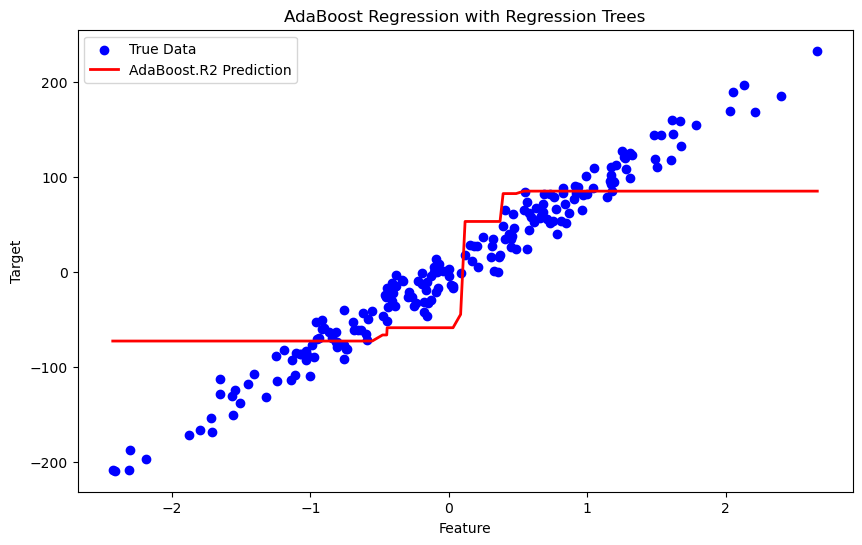

In [ ]:
# Generate regression data
X, y = make_regression(n_samples=200,n_features=1,noise=15,random_state=1450)

# Sort data for cleaner plotting
sorted_idx = np.argsort(X[:, 0])

X = X[sorted_idx]
y = y[sorted_idx]


# Create regression stump
base_learner = DecisionTreeRegressor(max_depth=1,random_state=1450)


# Create AdaBoost regressor
model = AdaBoostRegressor(
    estimator=base_learner,   # weak learner
    n_estimators=20,          # M boosting rounds
    learning_rate=0.5,        # eta
    loss="linear",            # AdaBoost.R2 loss
    random_state=1450
)


# Train model
model.fit(X, y)


# Predictions
y_pred = model.predict(X)


# Evaluate model
mae = mean_absolute_error(y, y_pred)
print(f"MAE: {mae:.4f}")


# Plot predictions
plt.figure(figsize=(10, 6))

plt.scatter(X,y,label="True Data",c="blue")

plt.plot(X,y_pred,linewidth=2,label="AdaBoost.R2 Prediction",c="red")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("AdaBoost Regression with Regression Trees")

plt.legend()
plt.show()